# Rappresentazione di un modello lineare

In questo notebook vedremo come rappresentare un modello di regressione lineare con una sola variabile.

L'obiettivo è costruire passo dopo passo una funzione che riceve un valore in ingresso e produce una previsione. Useremo un esempio semplice: stimare il prezzo di una casa a partire dalla sua dimensione.

## Obiettivi

Alla fine del notebook saprai:

- creare un piccolo insieme di dati con Python;
- leggere il numero di esempi disponibili;
- accedere a un singolo esempio;
- disegnare i dati su un grafico;
- implementare il modello lineare $f_{w,b}(x) = wx + b$;
- modificare i parametri `w` e `b` per osservare come cambia la previsione.

## Notazione essenziale

| Simbolo | Significato | Nome nel codice |
|---|---|---|
| $x$ | valore in ingresso, in questo esempio la dimensione della casa | `x_train` |
| $y$ | valore da prevedere, in questo esempio il prezzo | `y_train` |
| $m$ | numero di esempi disponibili | `m` |
| $w$ | parametro del modello chiamato pendenza o coefficiente angolare: controlla quanto la retta sale quando `x` aumenta | `w` |
| $b$ | parametro del modello chiamato intercetta sull'asse y, o ordinata all'origine: indica dove la retta incontra l'asse verticale | `b` |
| $f_{w,b}(x)$ | previsione prodotta dal modello | `f_wb` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Scenario

Vogliamo stimare il prezzo di una casa partendo dalla sua dimensione.

Useremo due esempi:

| Dimensione casa | Prezzo |
|---|---|
| 1000 sqft | 300 mila dollari |
| 2000 sqft | 500 mila dollari |

Per rendere i numeri più semplici, rappresentiamo la dimensione in migliaia di sqft:

- 1000 sqft diventa `1.0`;
- 2000 sqft diventa `2.0`.

Anche il prezzo è espresso in migliaia di dollari. Quindi `300` significa 300 mila dollari.

## 1. Creiamo i dati

I valori di ingresso saranno salvati in `x_train`, mentre i valori da prevedere saranno salvati in `y_train`.

In [2]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


## 2. Numero di esempi

La variabile `m` indica quanti esempi abbiamo. In questo caso gli esempi sono due.

Un array ha una forma, leggibile con `.shape`. Per un array monodimensionale, il primo valore della forma corrisponde al numero di elementi.

In [3]:
print(f"Forma di x_train: {x_train.shape}")
m = x_train.shape[0]
print(f"Numero di esempi: {m}")

Forma di x_train: (2,)
Numero di esempi: 2


Possiamo ottenere lo stesso risultato anche con `len()`, che restituisce la lunghezza dell'array.

In [4]:
m = len(x_train)
print(f"Numero di esempi: {m}")

Numero di esempi: 2


## 3. Leggere un singolo esempio

In Python gli indici partono da zero:

- l'esempio con indice `0` è il primo esempio;
- l'esempio con indice `1` è il secondo esempio.

Modifica `i` nella cella seguente per osservare un esempio diverso.

In [5]:
i = 0

x_i = x_train[i]
y_i = y_train[i]

print(f"Esempio {i}: dimensione = {x_i}, prezzo = {y_i}")

Esempio 0: dimensione = 1.0, prezzo = 300.0


## 4. Visualizzare i dati

Un grafico aiuta a vedere la relazione tra dimensione e prezzo. Ogni punto rappresenta una casa del nostro piccolo insieme di dati.

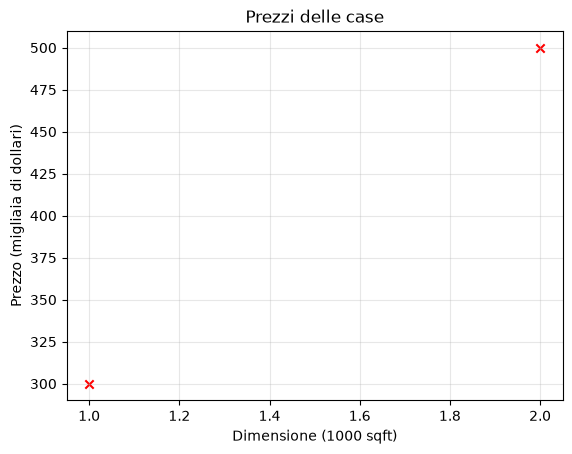

In [6]:
plt.scatter(x_train, y_train, marker='x', color='red')
plt.title('Prezzi delle case')
plt.xlabel('Dimensione (1000 sqft)')
plt.ylabel('Prezzo (migliaia di dollari)')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Il modello lineare

Un modello lineare con una variabile usa questa forma:

$$f_{w,b}(x) = wx + b$$

Questa retta è un modello: è molto semplice, ma è comunque una regola che usa un valore in ingresso `x` per produrre una previsione. Nel nostro esempio, prende la dimensione di una casa e restituisce un prezzo stimato.

I valori `w` e `b` sono chiamati parametri del modello, perché determinano il comportamento della retta:

- `w` è la pendenza, detta anche coefficiente angolare. Indica quanto cambia la previsione quando `x` aumenta di 1;
- `b` è l'intercetta sull'asse y, detta anche ordinata all'origine. Indica il valore della retta quando `x = 0`.

Valori diversi di `w` e `b` producono rette diverse, quindi producono modelli diversi. Iniziamo con una scelta non perfetta, così possiamo vedere l'effetto sul grafico.

In [7]:
w = 100
b = 100

print(f"w = {w}")
print(f"b = {b}")

w = 100
b = 100


## 6. Calcolare le previsioni del modello

Per ogni valore `x`, il modello calcola:

```python
previsione = w * x + b
```

### Tasks:
1. Scriviamo la funzione del modello lineare base – una retta.
2. Scriviamo una funzione che applica questa regola a tutti gli esempi disponibili.

In [8]:
# Completa la definizione della funzione lineare. 
# Nota: la funzione della retta si aspetta 3 parametri scalari.

def f_wb(w, x_train, b):   
    return  w * x_train + b

# La funzione `calcola_previsioni` implementa la funzione della `f_wb` per calcolare le previsioni del modello
# per ogni punto del dataset – Nota: il parametro `x` qui sotto, non è più uno scalare, ma un 1d array

def calcola_previsioni(x, w, b):
    m = len(x_train) # da modificare – indica quante previsioni dobbiamo effettuare
    previsioni = np.zeros(m) # da modificare – inizializzare il Numpy array di shape (2, 0)

    for i in range(m):
        # calcola la previsione ed assegnala al corretto indice di `previsioni`
        previsioni[i]=f_wb(w, x_train[i], b)
    

    return previsioni

Ora usiamo la funzione e confrontiamo la retta del modello con i dati reali.

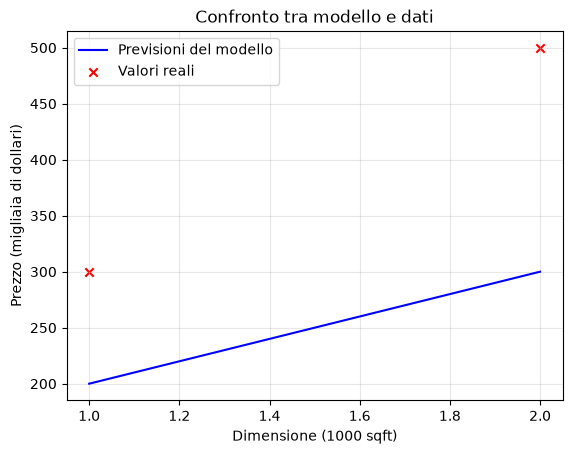

In [9]:
previsioni = calcola_previsioni(x_train, w, b)

plt.plot(x_train, previsioni, color='blue', label='Previsioni del modello')
plt.scatter(x_train, y_train, marker='x', color='red', label='Valori reali')
plt.title('Confronto tra modello e dati')
plt.xlabel('Dimensione (1000 sqft)')
plt.ylabel('Prezzo (migliaia di dollari)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Con `w = 100` e `b = 100`, la retta non passa bene attraverso i due punti. Proviamo una scelta migliore.

### Esercizio guidato

Modifica i valori di `w` e `b` nella cella seguente. Troviamo una combinazione di `w` e `b`che produca dei risultati migliori.

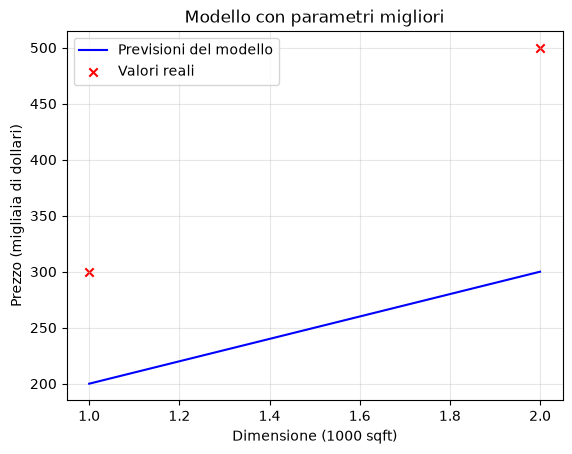

Previsioni: [200. 300.]
Valori reali: [300. 500.]


In [10]:
w = 100 # modifica
b = 100 # modifica

previsioni = calcola_previsioni(x_train, w, b)

plt.plot(x_train, previsioni, color='blue', label='Previsioni del modello')
plt.scatter(x_train, y_train, marker='x', color='red', label='Valori reali')
plt.title('Modello con parametri migliori')
plt.xlabel('Dimensione (1000 sqft)')
plt.ylabel('Prezzo (migliaia di dollari)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Previsioni: {previsioni}")
print(f"Valori reali: {y_train}")

## 7. Fare una nuova previsione

Ora usiamo il modello per stimare il prezzo di una casa da 1200 sqft.

Poiché la dimensione è espressa in migliaia di sqft, 1200 sqft diventa `1.2`.

Prezzo previsto: None mila dollari


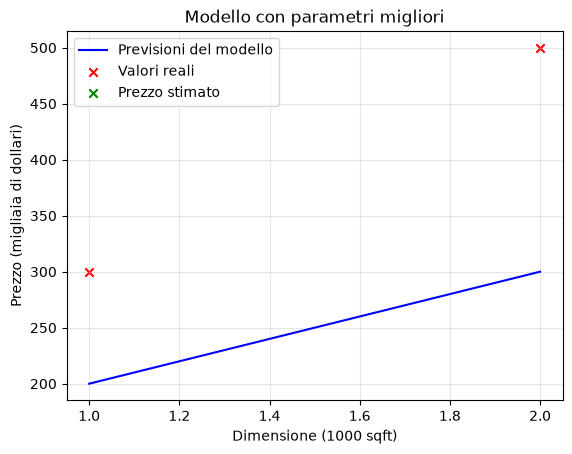

In [ ]:
x_nuova_casa = 1.2
prezzo_previsto = None # stima il prezzo di una nuova casa con dimensione `x_nuova_casa`

print(f"Prezzo previsto: {prezzo_previsto:.0f} mila dollari")

plt.plot(x_train, previsioni, color='blue', label='Previsioni del modello')
plt.scatter(x_train, y_train, marker='x', color='red', label='Valori reali')

plt.scatter(x_nuova_casa, prezzo_previsto, marker='x', color='green', label='Prezzo stimato')

plt.title('Modello con parametri migliori')
plt.xlabel('Dimensione (1000 sqft)')
plt.ylabel('Prezzo (migliaia di dollari)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Riepilogo

In questo notebook hai visto che:

- un modello lineare può rappresentare una relazione tra una variabile di ingresso e un valore da prevedere;
- i parametri `w` e `b` determinano la forma della retta;
- cambiando `w` e `b`, cambiano anche le previsioni;
- una volta scelti i parametri, il modello può essere usato per fare previsioni su nuovi valori.